In [522]:
import numpy as np
import pandas as pd

In [523]:
url = 'https://raw.githubusercontent.com/Rabiul-ds/Melbourne-housing-market-price-prediction/refs/heads/main/Melbourne_housing_FULL.csv'
df_i = pd.read_csv(url, encoding='utf-8')
df_i.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34857 entries, 0 to 34856
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         34857 non-null  object 
 1   Address        34857 non-null  object 
 2   Rooms          34857 non-null  int64  
 3   Type           34857 non-null  object 
 4   Price          27247 non-null  float64
 5   Method         34857 non-null  object 
 6   SellerG        34857 non-null  object 
 7   Date           34857 non-null  object 
 8   Distance       34856 non-null  float64
 9   Postcode       34856 non-null  float64
 10  Bedroom2       26640 non-null  float64
 11  Bathroom       26631 non-null  float64
 12  Car            26129 non-null  float64
 13  Landsize       23047 non-null  float64
 14  BuildingArea   13742 non-null  float64
 15  YearBuilt      15551 non-null  float64
 16  CouncilArea    34854 non-null  object 
 17  Lattitude      26881 non-null  float64
 18  Longti

# **Part A: Data Preprocessing & EDA**

**Duplicate Removal**

In [524]:
df_i[df_i.duplicated()]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
15858,Nunawading,1/7 Lilian St,3,t,NaN,SP,Jellis,17/06/2017,15.4,3131.0,...,3.0,2.0,405.0,226.0,2000.0,Manningham City Council,-37.82678,145.16777,Eastern Metropolitan,4973.0


In [525]:
df_i.drop_duplicates(inplace=True)

In [526]:
df_i[df_i.duplicated()]

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount


**Missing value treatment**

In [527]:
print(df_i.isnull().sum())

Suburb               0
Address              0
Rooms                0
Type                 0
Price             7609
Method               0
SellerG              0
Date                 0
Distance             1
Postcode             1
Bedroom2          8217
Bathroom          8226
Car               8728
Landsize         11810
BuildingArea     21115
YearBuilt        19306
CouncilArea          3
Lattitude         7976
Longtitude        7976
Regionname           3
Propertycount        3
dtype: int64


In [528]:
#All object-type columns converted to Category type
columns_to_convert = df_i.select_dtypes(include=['object']).columns
df_i[columns_to_convert] = df_i[columns_to_convert].astype('category')
df_i.head(5)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,2.5,3067.0,...,1.0,1.0,126.0,NaN,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra City Council,-37.7996,144.9984,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.8079,144.9934,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,2.5,3067.0,...,2.0,1.0,0.0,NaN,NaN,Yarra City Council,-37.8114,145.0116,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.8093,144.9944,Northern Metropolitan,4019.0


In [529]:
#Correlation finding for category type colums vs price
categorical_cols = df_i.select_dtypes(include=['category']).columns
corr_with_price_cat = {}

for col in categorical_cols:
    corr = df_i[col].cat.codes.corr(df_i['Price'])
    corr_with_price_cat[col] = corr

corr_with_price_cat = pd.Series(corr_with_price_cat).sort_values()
print(corr_with_price_cat)


Type          -0.369301
Suburb        -0.136648
CouncilArea   -0.108260
SellerG       -0.046206
Date          -0.012643
Method        -0.011019
Address        0.038803
Regionname     0.076319
dtype: float64


In [530]:
# #Correlation finding for numeric types colums vs price
numeric_cols = df_i.select_dtypes(include=['float64', 'int64']).columns.drop('Price')
corr_with_price_num = df_i[numeric_cols].corrwith(df_i['Price']).sort_values()

print(corr_with_price_num)

YearBuilt       -0.333306
Lattitude       -0.215607
Distance        -0.211384
Propertycount   -0.059017
Landsize         0.032748
Postcode         0.044950
BuildingArea     0.100754
Longtitude       0.197874
Car              0.201803
Bathroom         0.429878
Bedroom2         0.430275
Rooms            0.465238
dtype: float64


Less than -0.3 (e.g., -0.4, -0.5)
greater than 0.3( e.g., 0.4, 0.5)/keep

In [531]:
# low significant/corelated colums are dropped
cols_to_drop = [
    'Postcode', 'Car', 'Landsize', 'BuildingArea', 'Lattitude','Distance','Longtitude','Propertycount','CouncilArea', 'SellerG', 'Date', 'Method', 'Regionname', 'Address']

df = df_i.drop(columns=cols_to_drop, errors='ignore')

In [532]:
# is it a normal distribution or not?
from scipy.stats import normaltest

numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    data = df[col].dropna()
    stat, p = normaltest(data)
    print(f"Column: {col}")
    print(f"  D’Agostino’s K² Test p-value = {p:.5f}")
    if p > 0.05:
        print("Data looks normally distributed.\n")
    else:
        print("Data is not normally distributed.\n")

Column: Rooms
  D’Agostino’s K² Test p-value = 0.00000
Data is not normally distributed.

Column: Price
  D’Agostino’s K² Test p-value = 0.00000
Data is not normally distributed.

Column: Bedroom2
  D’Agostino’s K² Test p-value = 0.00000
Data is not normally distributed.

Column: Bathroom
  D’Agostino’s K² Test p-value = 0.00000
Data is not normally distributed.

Column: YearBuilt
  D’Agostino’s K² Test p-value = 0.00000
Data is not normally distributed.



In [533]:
print(df.isnull().sum())

Suburb           0
Rooms            0
Type             0
Price         7609
Bedroom2      8217
Bathroom      8226
YearBuilt    19306
dtype: int64


Rooms: 33 outliers detected
Price: 1278 outliers detected
Bedroom2: 26 outliers detected
Bathroom: 371 outliers detected
YearBuilt: 5 outliers detected


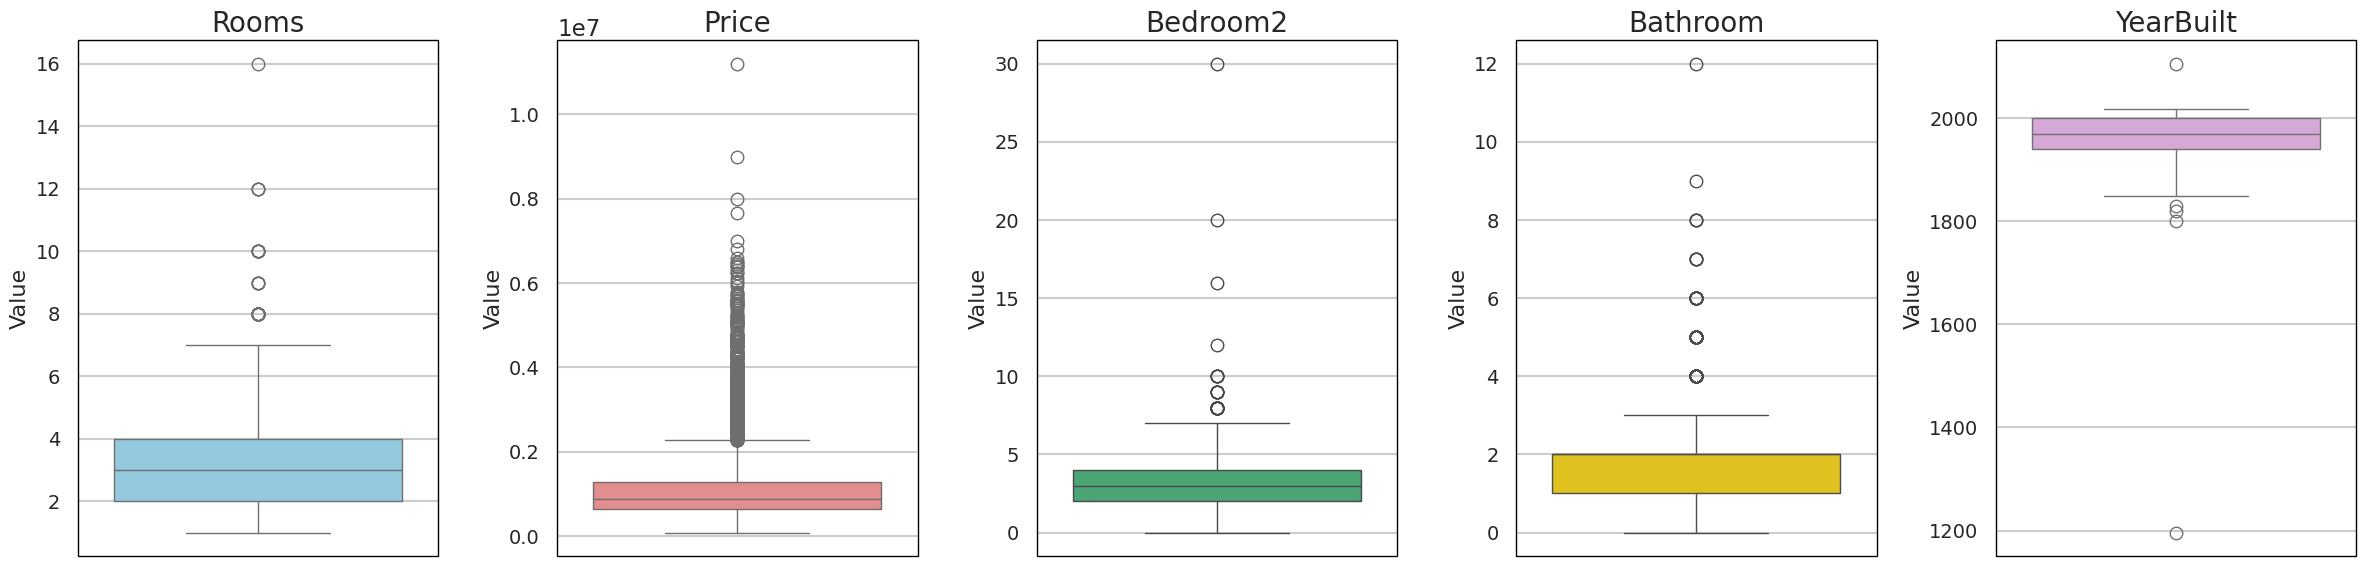

In [534]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

numeric_cols = df.select_dtypes(include='number').columns[:5]
colors_before = ['skyblue', 'lightcoral', 'mediumseagreen', 'gold', 'plum']

title_fontsize = 20
label_fontsize = 16
tick_labelsize = 14

fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(24, 6), sharey=False)
outlier_masks = {}

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    sns.boxplot(data=df, y=col, ax=ax, color=colors_before[i])
    ax.set_title(col, fontsize=title_fontsize)
    ax.set_xlabel('', fontsize=label_fontsize)
    ax.set_ylabel('Value', fontsize=label_fontsize)
    ax.tick_params(axis='y', labelsize=tick_labelsize)
    ax.tick_params(axis='x', labelsize=tick_labelsize)

    # Remove spines
    for spine in ax.spines.values():
        spine.set_visible(False)

    data = df[col].dropna()
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    outlier_masks[col] = outlier_mask

    print(f"{col}: {outlier_mask.sum()} outliers detected")

plt.tight_layout()
fig.canvas.draw()

# Rectangle frames
for ax in axes:
    bbox = ax.get_position()
    rect = Rectangle(
        (bbox.x0, bbox.y0), bbox.width, bbox.height,
        linewidth=1, edgecolor='black', facecolor='none',
        transform=fig.transFigure, zorder=10
    )
    fig.patches.append(rect)

plt.show()

# Outliers with NaN
for col in numeric_cols:
    df.loc[outlier_masks[col], col] = np.nan

In [535]:
print(df.isnull().sum())

Suburb           0
Rooms           33
Type             0
Price         8887
Bedroom2      8243
Bathroom      8597
YearBuilt    19311
dtype: int64


In [536]:
df['Rooms'] = df['Rooms'].fillna(df.groupby(['Bedroom2', 'Bathroom'])['Rooms'].transform('median'))
df['Rooms'] = df['Rooms'].fillna(df['Rooms'].median()).round()

In [537]:
# Fill missing values
df['Bathroom'] = df['Bathroom'].fillna(df.groupby('Rooms')['Bathroom'].transform('median')).round()
df['Bedroom2'] = df['Bedroom2'].fillna(df.groupby('Rooms')['Bedroom2'].transform('median')).round()

In [538]:
df.isna().sum()

,0
Suburb,0
Rooms,0
Type,0
Price,8887
Bedroom2,0
Bathroom,0
YearBuilt,19311


In [539]:
# Finally unnecessary colums are dropped
df.drop(columns=["Address", "Date"], inplace=True, errors='ignore')

In [540]:
df.isna().sum()

,0
Suburb,0
Rooms,0
Type,0
Price,8887
Bedroom2,0
Bathroom,0
YearBuilt,19311


In [541]:
#Price is strongly correlated with Rooms, Bedroom2, and Bathroom
df['Price'] = df['Price'].fillna(df.groupby(['Rooms', 'Bedroom2', 'Bathroom'])['Price'].transform('median'))

In [542]:
# Fill YearBuilt using median of Suburb + Type
df['YearBuilt'] = df['YearBuilt'].fillna(
    df.groupby(['Suburb', 'Type'])['YearBuilt'].transform('median'))

# Fill remaining with Suburb median
df['YearBuilt'] = df['YearBuilt'].fillna(
    df.groupby('Suburb')['YearBuilt'].transform('median'))

# Fill remaining with global median
df['YearBuilt'] = df['YearBuilt'].fillna(df['YearBuilt'].median())


/tmp/ipython-input-542-2264249343.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Suburb', 'Type'])['YearBuilt'].transform('median'))
/tmp/ipython-input-542-2264249343.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Suburb')['YearBuilt'].transform('median'))


In [543]:
df.isna().sum()

,0
Suburb,0
Rooms,0
Type,0
Price,16
Bedroom2,0
Bathroom,0
YearBuilt,0


In [544]:
# Drop missing all rows in Price, subard and price
df.dropna(axis=0, subset="Price", inplace=True)
df_dropped = df.drop(columns=['Suburb', 'Type'], inplace=False)
df_dropped.isna().sum()

,0
Rooms,0
Price,0
Bedroom2,0
Bathroom,0
YearBuilt,0


**Summary Stat**

In [545]:
numeric_df = df_dropped.select_dtypes(include='number')
summary = numeric_df.agg(['count', 'mean', 'median', 'std', 'min', 'max']).T
summary['mode'] = numeric_df.mode().iloc[0]
print(summary)

             count           mean    median            std      min  \
Rooms      34840.0       3.024397       3.0       0.949502      1.0   
Price      34840.0  954024.454420  870000.0  392446.285531  85000.0   
Bedroom2   34840.0       3.010850       3.0       0.947818      0.0   
Bathroom   34840.0       1.503330       1.0       0.617762      0.0   
YearBuilt  34840.0    1965.593241    1970.0      32.919481   1850.0   

                 max       mode  
Rooms            7.0        3.0  
Price      2285000.0  1100000.0  
Bedroom2         7.0        3.0  
Bathroom         3.0        1.0  
YearBuilt     2019.0     1970.0  


In [546]:
summary.style.background_gradient(cmap='Blues').format(precision=2)

,count,mean,median,std,min,max,mode
Rooms,34840.00,3.02,3.00,0.95,1.00,7.00,3.00
Price,34840.00,954024.45,870000.00,392446.29,85000.00,2285000.00,1100000.00
Bedroom2,34840.00,3.01,3.00,0.95,0.00,7.00,3.00
Bathroom,34840.00,1.50,1.00,0.62,0.00,3.00,1.00
YearBuilt,34840.00,1965.59,1970.00,32.92,1850.00,2019.00,1970.00


# **Data Visualization**

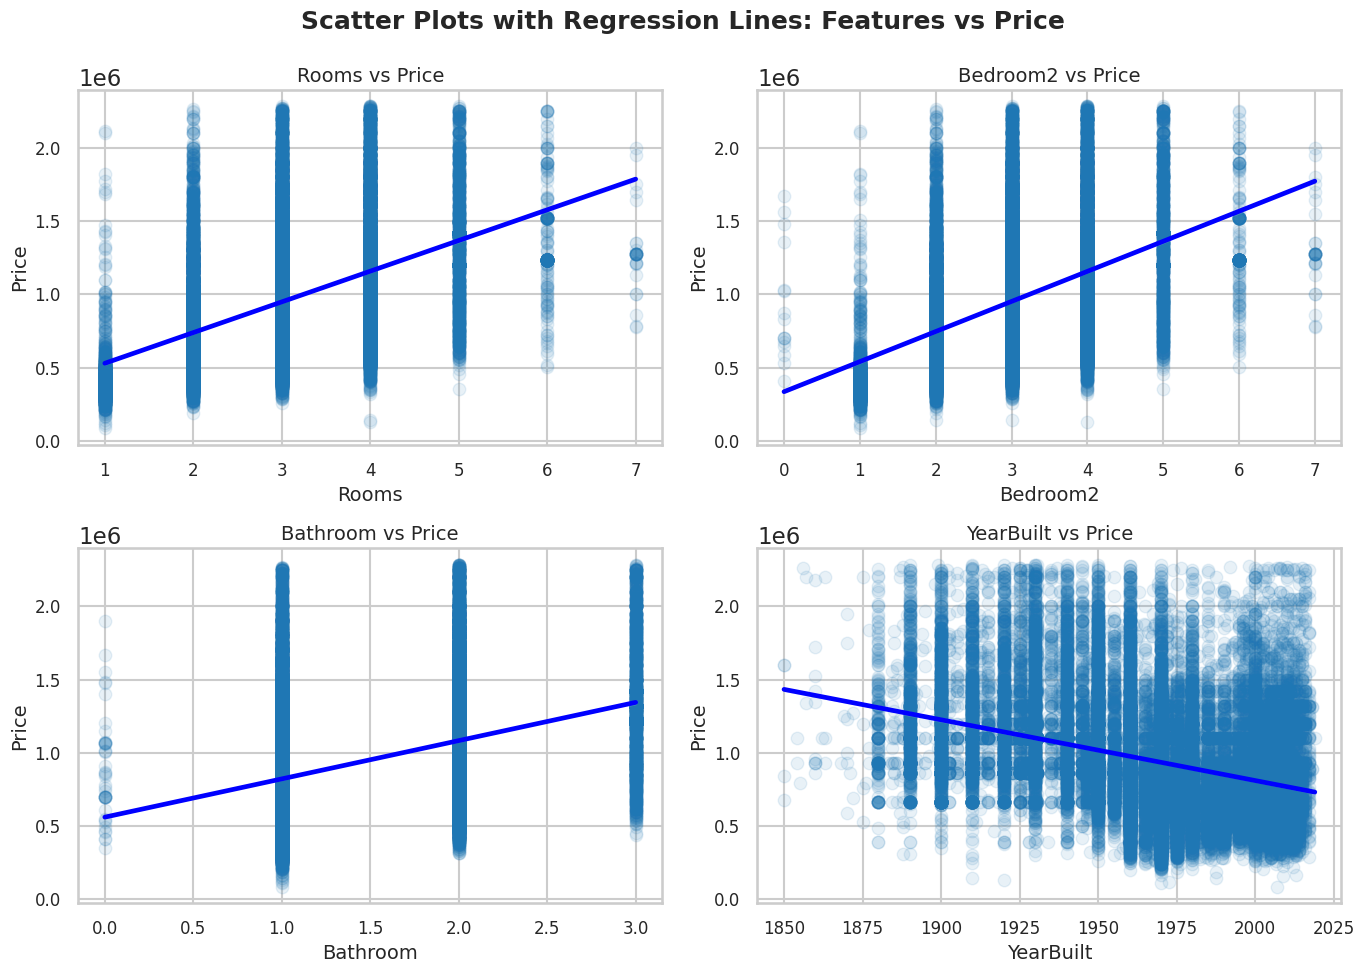

In [547]:
sns.set(style="whitegrid", context="talk")
features = ["Rooms", "Bedroom2", "Bathroom", "YearBuilt"]

#Subplots
n = len(features)
cols = 2
rows = (n + cols - 1) // cols

# Subplots Creation
fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.regplot(
        ax=axes[i],
        data=df_dropped,
        x=feature,
        y="Price",
        scatter_kws={"alpha": 0.1, "color": "#1f77b4"},
        line_kws={"color": "blue"},
    )
    axes[i].set_title(f"{feature} vs Price", fontsize=14)
    axes[i].set_xlabel(feature, fontsize=14)
    axes[i].set_ylabel("Price", fontsize=14)
    axes[i].tick_params(axis='both', labelsize=12)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()
fig.subplots_adjust(top=0.90)


fig.suptitle(
    "Scatter Plots with Regression Lines: Features vs Price",
    fontsize=18,
    fontweight="bold"
)

plt.show()


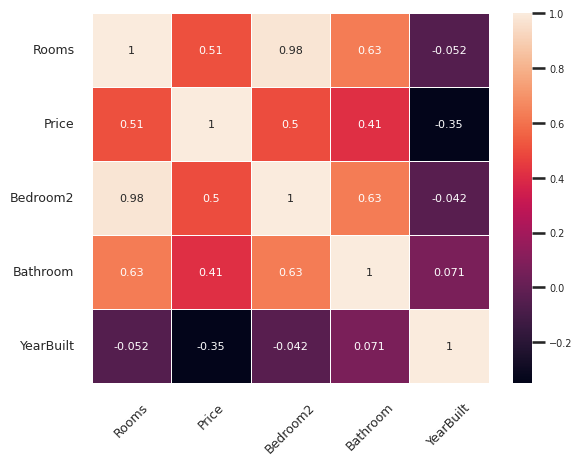

In [548]:
ax = sns.heatmap(
    df_dropped.corr(numeric_only=True).T,
    annot=True,
    linewidths=0.5,
    annot_kws={"fontsize": 8}
)

plt.xticks(fontsize=9, rotation=45)
plt.yticks(fontsize=9, rotation=0)

colorbar = ax.collections[0].colorbar
colorbar.ax.tick_params(labelsize=7)
plt.show()

# **Hypothesis Testing**

1. 2-bedroom and 3-bedroom houses in your dataset are statistically different or not.

In [549]:
import scipy.stats as stats
group_2_bed = df_dropped[df_dropped['Bedroom2'] == 2]['Price'].dropna()
group_3_bed = df_dropped[df_dropped['Bedroom2'] == 3]['Price'].dropna()

t_stat, p_value = stats.ttest_ind(group_2_bed, group_3_bed, equal_var=False)
alpha = 0.05

print("🔍 Hypothesis Testing: Welch's Two-Sample T-Test")
print("Test Details:")
print("  - Null Hypothesis (H₀): Mean price of 2-bedroom homes = Mean price of 3-bedroom homes")
print("  - Alternative Hypothesis (H₁): Mean prices of 2-bedroom and 3-bedroom homes differ")
print(f"  - Significance Level (α): {alpha}")
print(f"Test Statistics:")
print(f"  - T-statistic: {t_stat:.3f}")
print(f"  - P-value: {p_value:.4f}")

if p_value < alpha:
    print("Conclusion: Reject H₀ — significant difference in mean prices between 2 and 3 bedroom homes.")
else:
    print("Conclusion: Fail to reject H₀ — no significant difference in mean prices between the two groups.")


🔍 Hypothesis Testing: Welch's Two-Sample T-Test
Test Details:
  - Null Hypothesis (H₀): Mean price of 2-bedroom homes = Mean price of 3-bedroom homes
  - Alternative Hypothesis (H₁): Mean prices of 2-bedroom and 3-bedroom homes differ
  - Significance Level (α): 0.05
Test Statistics:
  - T-statistic: -52.796
  - P-value: 0.0000
Conclusion: Reject H₀ — significant difference in mean prices between 2 and 3 bedroom homes.


Hypothesis 2

Rooms (2 vs 3):
H₀: Mean price (2 rooms) = Mean price (3 rooms)
H₁: Mean price (2 rooms) ≠ Mean price (3 rooms)

Bathroom (1 vs 2):
H₀: Mean price (1 bath) = Mean price (2 baths)
H₁: Mean price (1 bath) ≠ Mean price (2 baths)

YearBuilt (2000 vs 2010):
H₀: Mean price (built in 2000) = Mean price (built in 2010)
H₁: Mean price (built in 2000) ≠ Mean price (built in 2010)

In [550]:
target = 'Price'
alpha = 0.05

columns = ['Rooms', 'Bathroom', 'YearBuilt']
compare_values = {
    'Rooms': (2, 3),
    'Bathroom': (1, 2),
    'YearBuilt': (2000, 2010)
}

for col in columns:
    val1, val2 = compare_values[col]

    group1 = df_dropped[df_dropped[col] == val1][target]
    group2 = df_dropped[df_dropped[col] == val2][target]

    if len(group1) == 0 or len(group2) == 0:
        print(f"Skipping {col}: one of the groups is empty.\n")
        continue

    t_stat, p_value = stats.ttest_ind(group1, group2, equal_var=False)

    print(f"Welch's T-Test on '{col}' — Comparing {val1} vs {val2}")
    print(f" Null Hypothesis (H₀): Mean prices are equal")
    print(f" Alternative Hypothesis (H₁): Mean prices differ")
    print(f" T-statistic: {t_stat:.3f}")
    print(f" P-value: {p_value:.4f}")

    if p_value < alpha:
        print(f"Conclusion: Reject H₀ — significant difference in mean prices.\n")
    else:
        print(f"Conclusion: Fail to reject H₀ — no significant difference.\n")

Welch's T-Test on 'Rooms' — Comparing 2 vs 3
 Null Hypothesis (H₀): Mean prices are equal
 Alternative Hypothesis (H₁): Mean prices differ
 T-statistic: -54.660
 P-value: 0.0000
Conclusion: Reject H₀ — significant difference in mean prices.

Welch's T-Test on 'Bathroom' — Comparing 1 vs 2
 Null Hypothesis (H₀): Mean prices are equal
 Alternative Hypothesis (H₁): Mean prices differ
 T-statistic: -63.583
 P-value: 0.0000
Conclusion: Reject H₀ — significant difference in mean prices.

Welch's T-Test on 'YearBuilt' — Comparing 2000 vs 2010
 Null Hypothesis (H₀): Mean prices are equal
 Alternative Hypothesis (H₁): Mean prices differ
 T-statistic: 3.082
 P-value: 0.0021
Conclusion: Reject H₀ — significant difference in mean prices.



# **4. Part C: Linear Regression Modeling**

Splitting the dataset

In [551]:
from sklearn.model_selection import train_test_split

X = df_dropped[['Rooms']]
y = df_dropped['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Simple Linear Regression (1 Predictor)

In [552]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_simple_scaled = X_train_scaled_df[['Rooms']]

model_simple = LinearRegression()
model_simple.fit(X_simple_scaled, y_train)

y_pred_simple = model_simple.predict(X_simple_scaled)

intercept = model_simple.intercept_
coef = model_simple.coef_[0]

print("Coefficient for 'Rooms':", coef)
print("Intercept:", intercept)
print(f"Regression equation: y = {intercept:.3f} + {coef:.3f} * Rooms")


Coefficient for 'Rooms': 198509.40390353696
Intercept: 955769.8263131458
Regression equation: y = 955769.826 + 198509.404 * Rooms


In [553]:
from sklearn.metrics import mean_squared_error

r2_simple = model_simple.score(X_simple_scaled, y_train)
rmse_simple = np.sqrt(mean_squared_error(y_train, y_pred_simple))

print(f"R² Score (Simple Model): {r2_simple:.3f}")
print(f"RMSE (Simple Model): {rmse_simple:.2f}")


R² Score (Simple Model): 0.256
RMSE (Simple Model): 338375.81


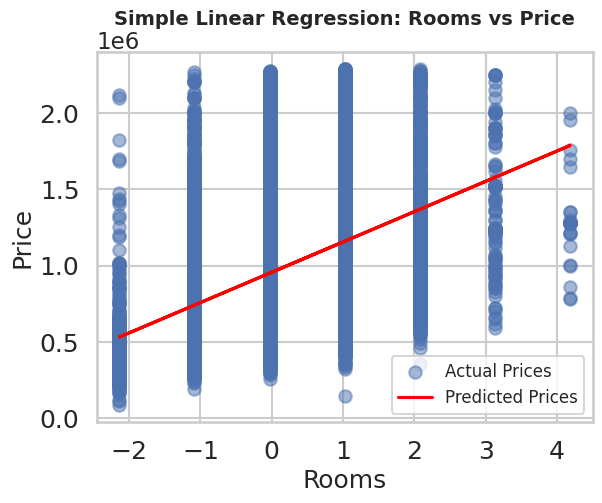

In [554]:
plt.scatter(X_simple_scaled, y_train, alpha=0.5, label='Actual Prices')
plt.plot(X_simple_scaled, y_pred_simple, color='red', label='Predicted Prices')
plt.xlabel('Rooms', fontsize=18,)
plt.ylabel('Price', fontsize=18,)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.title('Simple Linear Regression: Rooms vs Price', fontsize=14, pad=20,fontweight="bold")
plt.legend(fontsize=12)
plt.show()

Residual Plot

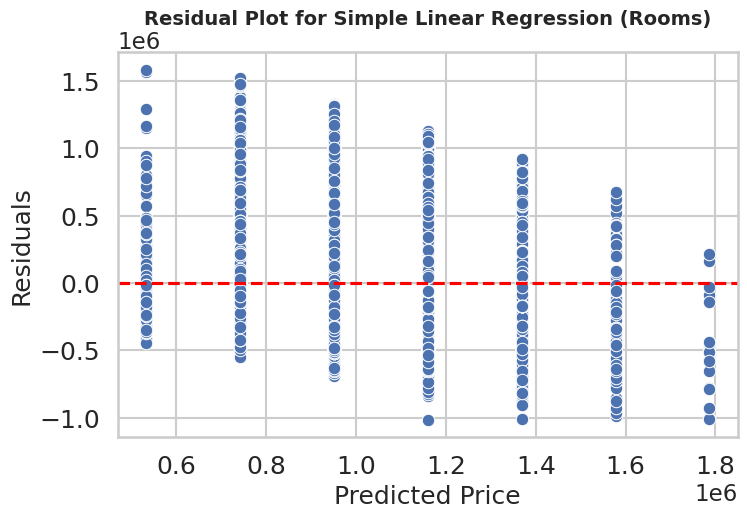

In [555]:
residuals_simple = y_train - y_pred_simple

plt.figure(figsize=(8,5))
sns.scatterplot(x=y_pred_simple, y=residuals_simple)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Price', fontsize=18)
plt.ylabel('Residuals', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.title('Residual Plot for Simple Linear Regression (Rooms)',fontsize=14, pad=20, fontweight="bold")
plt.show()


Multiple Linear Regression (Predictors: Rooms, Distance,Bedroom2)

In [556]:
features = ['Bedroom2', 'Bathroom','YearBuilt']
X_multi = df_dropped[features]
y_multi = df_dropped['Price']

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled_multi = scaler.fit_transform(X_train_multi)
X_test_scaled_multi = scaler.transform(X_test_multi)

model_multi = LinearRegression()
model_multi.fit(X_train_scaled_multi, y_train_multi)
y_pred_multi = model_multi.predict(X_test_scaled_multi)
r2_multi = model_multi.score(X_test_scaled_multi, y_test_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test_multi, y_pred_multi))

print(f"Multiple Linear Regression R²: {r2_multi:.4f}")
print(f"Multiple Linear Regression RMSE: {rmse_multi:.2f}")


Multiple Linear Regression R²: 0.3946
Multiple Linear Regression RMSE: 305704.07


In [557]:
coef_dict = dict(zip(features, model_multi.coef_))
print("Coefficients:")
for feature, coef in coef_dict.items():
    print(f"  {feature}: {coef:.3f}")
print(f"Intercept (bias): {model_multi.intercept_:.3f}")
terms = [f"({coef:.3f} × {feature})" for feature, coef in coef_dict.items()]
equation = " + ".join(terms)
full_equation = f"y = {model_multi.intercept_:.3f} + " + equation

print("\nRegression Equation:")
print(full_equation)

Coefficients:
  Bedroom2: 134368.928
  Bathroom: 86248.253
  YearBuilt: -135859.404
Intercept (bias): 955769.826

Regression Equation:
y = 955769.826 + (134368.928 × Bedroom2) + (86248.253 × Bathroom) + (-135859.404 × YearBuilt)


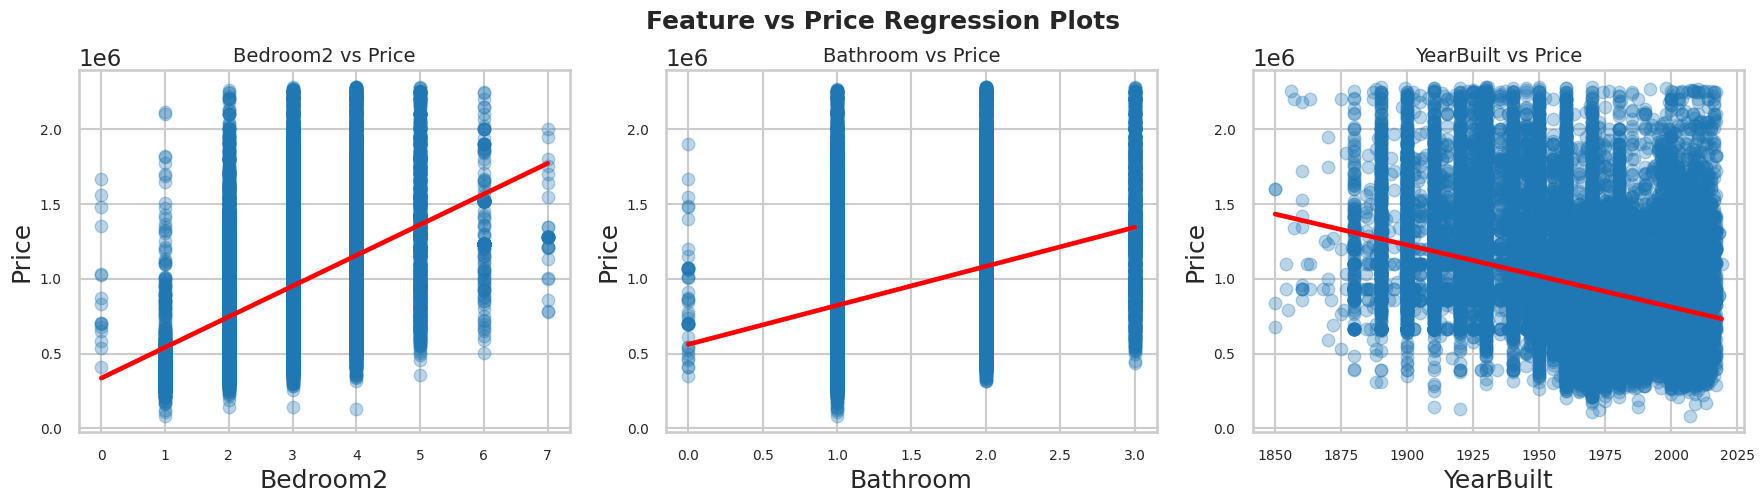

In [558]:
features = ['Bedroom2', 'Bathroom', 'YearBuilt']
rows = 1
cols = len(features)

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))

for i, feature in enumerate(features):
    sns.regplot(
        x=feature,
        y='Price',
        data=df_dropped,
        ax=axes[i],
        scatter_kws={"alpha": 0.3, "color": "#1f77b4"},
        line_kws={"color": "red"},
    )
    axes[i].set_title(f'{feature} vs Price', fontsize=14)
    axes[i].set_xlabel(feature, fontsize=18)
    axes[i].set_ylabel('Price', fontsize=18)
    axes[i].tick_params(axis='both', labelsize=10)

plt.tight_layout()
fig.suptitle("Feature vs Price Regression Plots", fontsize=18, y=1.02,fontweight="bold")
plt.show()


2. Residual Plot


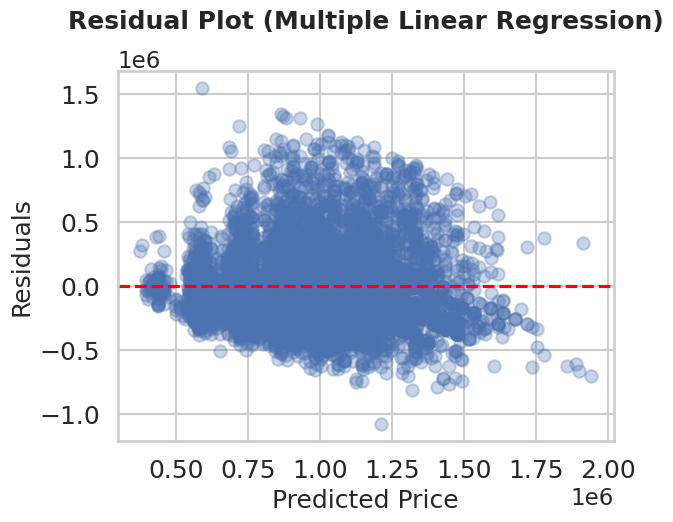

In [559]:
residuals = y_test_multi - y_pred_multi
plt.scatter(y_pred_multi, residuals, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel('Predicted Price', fontsize=18)
plt.ylabel('Residuals', fontsize=18)
plt.title('Residual Plot (Multiple Linear Regression)', fontsize=18, pad=15,fontweight="bold")
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True)
plt.show()
